# Main code for analyzing HAPPEN data

## Intro
Main code for analyzing data for paper Understanding the impact of conditionally repeated hemoglobin measurements in the Netherlands by Mart Pothast, Katja vd Hurk & Mart Janssen.

First the HAPPEN data is analyzed and the measurement uncertainty and population distribution is determined. Then the Hb distr of first time donors is analyzed.

To run the notebook you need numpy, pandas matplotlib, scipy and numba

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as scistats

from scipy.integrate import quad

#All the magic is imported from here, see there for implementation of pdfs
from cond_distr import *

def load_data(filename=None):
    if filename is None:
        filename = "/mnt/c/Users/potha01m/data/analysefile_Happen.sav"
        try:
            df = pd.read_spss(filename)
        except:
            filename = "/home/m.pothast/data/analysefile_Happen.sav"
            df = pd.read_spss(filename)
    else:
        df = pd.read_spss(filename)
    n = len(df)
    df.loc[:, "Geslacht_new"] = 0
    df.loc[df["Geslacht"] == "vrouw", "Geslacht_new"] = 1
    df["sex"] = df["Geslacht_new"]
    df["Hbv"] = df["Hbveneus"]
    df = df.reset_index()
    return df

In [2]:
true = 7.7
cut = 7.8
p1 = scistats.norm.sf(cut, true, 0.38)
p2 = 1-scistats.multivariate_normal.cdf([cut-0.05, cut-0.05], [true, true], [[0.38**2, 0], [0, 0.38**2]])
p3 = 1-scistats.multivariate_normal.cdf([cut-0.05, cut-0.05, cut-0.05], [true, true, true], [[0.38**2, 0, 0], [0, 0.38**2, 0], [0, 0, 0.38**2]])
p1, p2, p3

(np.float64(0.39621444120230037),
 np.float64(0.6949190542303118),
 np.float64(0.8314911843953401))

In [3]:
scistats.norm.cdf(7.75, 8.44, (0.52**2 + 0.37**2/3)**0.5)

np.float64(0.10983798747943169)

In [4]:
scistats.norm.cdf(8.35, 9.45, (0.56**2 + 0.38**2/3)**0.5)

np.float64(0.03370462612312476)

In [5]:
scistats.norm.cdf(8.35, 9.45, 0.56), scistats.norm.cdf(7.75, 8.44, 0.52)

(np.float64(0.024748483717871087), np.float64(0.09226706487403036))

## Load data

In [6]:
df = load_data()
print(f"Males = {len(df.loc[df['sex'] == 0])}")
print(f"Females = {len(df.loc[df['sex'] == 1])}")

Males = 1377
Females = 1230


In [7]:
#This is the procedure that is normally stored
def procedure(x1, x2, x3, cut):
    #strategy for sequential testing
    return np.where((x1 < cut)&np.isfinite(x2), np.where((x2 < cut)&np.isfinite(x3), np.nanmax([x1, x2, x3], axis=0), x2), x1)

df_m = df.query('sex == 0').copy()
df_f = df.query('sex == 1').copy()
df_m['Hb_max'] = procedure(df_m['Hb201a'], df_m['Hb201b'], df_m['Hb201c'], 8.4)
df_f['Hb_max'] = procedure(df_f['Hb201a'], df_f['Hb201b'], df_f['Hb201c'], 7.8)
df = pd.concat([df_m, df_f])

## Calculate percentages below cutoff

In [8]:
def calc_percentage_below_cut_data(data, cut, N=None):
    if N is None:
        bs = scistats.bootstrap((data,), lambda x: 100 * (x < cut).sum() / len(x))
    else:
        bs = scistats.bootstrap((data,), lambda x: 100 * (x < cut).sum() / N)

    # perc = (bs.bootstrap_distribution).mean()
    if N is None:
        perc = 100 * (data < cut).sum() / len(data)
    else:
        perc = 100 * (data < cut).sum() / N
    return (
        (data < cut).sum(),
        perc,
        bs.confidence_interval[0],
        bs.confidence_interval[1],
    )


def calc_all_percentages(df, cut, use_301=False):
    if use_301:
        hb1 = df["Hb301a"].values
        hb2 = df["Hb301b"].values
        hb3 = df["Hb301c"].values
    else:
        hb1 = df["Hb201a"].values
        hb2 = df["Hb201b"].values
        hb3 = df["Hb201c"].values
    N = np.isfinite(hb1).sum()
    N2 = np.isfinite(hb2).sum()
    N3 = np.isfinite(hb3).sum()
    print(f"{N2} = {N2/N*100:.2f}% are repeated once")
    print(f"{N3} = {N3/N*100:.2f}% are repeated twice")
    n1, p1, p1_low, p1_high = calc_percentage_below_cut_data(
        hb1,
        cut,
        N=N,
    )
    n2, p2, p2_low, p2_high = calc_percentage_below_cut_data(
        hb2[hb1 < cut],
        cut,
        N=N,
    )
    n3, p3, p3_low, p3_high = calc_percentage_below_cut_data(
        hb3[(hb1 < cut) & (hb2 < cut)],
        cut,
        N=N,
    )
    print(f"1st below {cut} = {n1}, {p1:.2f} [{p1_low:.2f}, {p1_high:.2f}]")
    print(f"2nd below {cut} = {n2}, {p2:.2f} [{p2_low:.2f}, {p2_high:.2f}]")
    print(f"3rd below {cut} = {n3}, {p3:.2f} [{p3_low:.2f}, {p3_high:.2f}]")

print("---------------")
print("201")
print("Females")
calc_all_percentages(df.loc[df["sex"] == 1], 7.8)
print("Males")
calc_all_percentages(df.loc[df["sex"] == 0], 8.4)
print("---------------")
# print("301")
# print("Females")
# calc_all_percentages(df.loc[df["sex"] == 1], 7.8, use_301=True)
# print("Males")
# calc_all_percentages(df.loc[df["sex"] == 0], 8.4, use_301=True)

---------------
201
Females
142 = 11.54% are repeated once
60 = 4.88% are repeated twice
1st below 7.8 = 141, 11.46 [9.76, 13.33]
2nd below 7.8 = 68, 5.53 [4.55, 6.50]
3rd below 7.8 = 39, 3.17 [2.52, 3.82]
Males
77 = 5.59% are repeated once
33 = 2.40% are repeated twice
1st below 8.4 = 74, 5.37 [4.28, 6.68]
2nd below 8.4 = 29, 2.11 [1.53, 2.69]
3rd below 8.4 = 15, 1.09 [0.73, 1.45]
---------------


## Calculate percentage of measurements that were done
But maybe should not have and vice-versa

In [9]:
def perc_of_meas_done(df, cut, meas='201'):
    print(meas)
    hba = df[f'Hb{meas}a'].values
    hbb = df[f'Hb{meas}b'].values
    hbc = df[f'Hb{meas}c'].values
    ntot = len(hba)
    low_a = hba < cut
    b = np.isfinite(hbb)
    n_low_a = low_a.sum()
    p_meas_b = (b&low_a).sum()/n_low_a
    
    print(f"Percetange of second measurement below cutoff and done: {(b&low_a).sum()/ntot*100:.2f} of total {low_a.sum()}")
    print(f"Percentage of second measurement that should have been done given first is below {cut}: {p_meas_b*100:.2f}%")
    print(f"percentage of second measurement w/out first < cut {(b&~low_a).sum()/ntot*100:.2f}")
    # plt.figure()
    print(scistats.kstest(hba[low_a&b], hba[low_a&~b]))
    # plt.hist(hba[low_a&b], cumulative=True, density=True, histtype='step', color='C0')
    # plt.hist(hba[low_a&~b], cumulative=True, density=True, histtype='step', color='C0', ls='--')

    low_b = hbb < cut
    c = np.isfinite(hbc)
    n_low_b = low_b.sum()
    p_meas_c = (c&low_b).sum()/n_low_b
    print(f"Percetange of third measurement below cutoff and done: {(c&low_b).sum()/ntot*100:.2f} of total {low_b.sum()}")
    print(f"Percentage of third measurement that should have been done given second is below {cut}: {p_meas_c*100:.2f}%")
    print(f"percentage of third measurement w/out second < cut {(c&~low_b).sum()/ntot*100:.2f}")
    # plt.hist(hbb[low_b&c], cumulative=True, density=True, histtype='step', color='C1')
    # plt.hist(hbb[low_b&~c], cumulative=True, density=True, histtype='step', color='C1', ls='--')
    print(scistats.kstest(hbb[low_b&c], hbb[low_b&~c]))
    
print("Males")
perc_of_meas_done(df.loc[df['sex'] == 0], 8.4)
print("--------")
print("Females")
perc_of_meas_done(df.loc[df['sex'] == 1], 7.8)
# print("Males")
# perc_of_meas_done(df.loc[df['sex'] == 0], 8.4, meas='301')
# print("--------")
# print("Females")
# perc_of_meas_done(df.loc[df['sex'] == 1], 7.8, meas='301')

Males
201
Percetange of second measurement below cutoff and done: 4.65 of total 74
Percentage of second measurement that should have been done given first is below 8.4: 86.49%
percentage of second measurement w/out first < cut 0.94
KstestResult(statistic=np.float64(0.234375), pvalue=np.float64(0.6482378705299677), statistic_location=np.float64(7.8), statistic_sign=np.int8(1))
Percetange of third measurement below cutoff and done: 1.53 of total 30
Percentage of third measurement that should have been done given second is below 8.4: 70.00%
percentage of third measurement w/out second < cut 0.87
KstestResult(statistic=np.float64(0.20634920634920634), pvalue=np.float64(0.9014445224939979), statistic_location=np.float64(8.1), statistic_sign=np.int8(-1))
--------
Females
201
Percetange of second measurement below cutoff and done: 10.41 of total 141
Percentage of second measurement that should have been done given first is below 7.8: 90.78%
percentage of second measurement w/out first < cut 1

## Uncertainty on cappilary measurement from difference between 1st and 2nd measurement
Using the correction factor as determined in `supplemental.ipynb`.
Because the correction factor depends mildy on sigma_pop, the procedure is iterated 10 times, in which pop_std is also estimated by subtracting sig_meas from sig_total. This works when starting with a good estimate of sigma_pop=0.55 (which is reasonable).

In [10]:
#Only get those measurements that you expect to get, i.e. remove those that have been repeated but were the measurement before was not below the threshold

def get_correct_repeated_meas(hb201a, hb201b, hb201c, cut):
    hb201b[hb201a >= cut] = np.nan
    hb201c[(hb201a >= cut)|(hb201b >= cut)] = np.nan
    return hb201a, hb201b, hb201c

df_f[['Hb201a_', 'Hb201b_', 'Hb201c_']] = pd.Series(get_correct_repeated_meas(df_f['Hb201a'].values, df_f['Hb201b'].values, df_f['Hb201c'].values, 7.8))
df_m[['Hb201a_', 'Hb201b_', 'Hb201c_']] = pd.Series(get_correct_repeated_meas(df_m['Hb201a'].values, df_m['Hb201b'].values, df_m['Hb201c'].values, 8.4))
df = pd.concat([df_f, df_m])

Male results:
Measurement uncertainty = 0.38, 95%CI [0.317, 0.440]
Std population = 0.56, 95%CI [0.502, 0.611]
Female results:
Measurement uncertainty = 0.37, 95%CI [0.300, 0.458]
Std population = 0.52, 95%CI [0.447, 0.577]


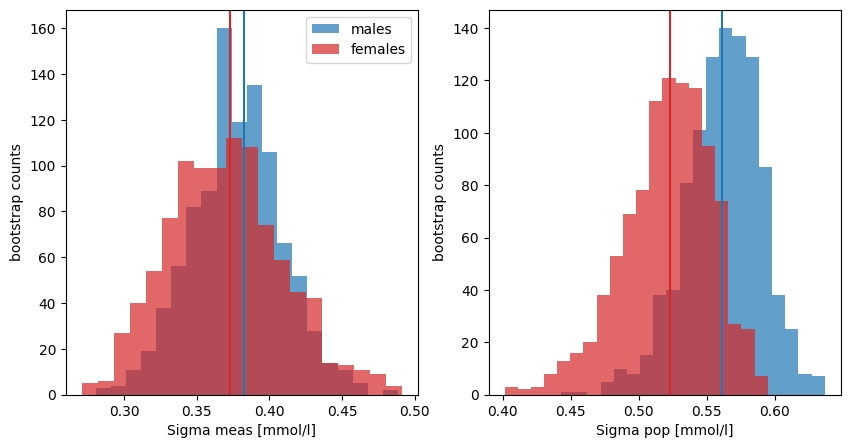

In [76]:
def compute_std_meas_cap(x1, x2, xv, n=10):
    hba_mean = np.mean(x1)
    hba_std = np.std(x1)
    # mask = np.isfinite(x2&x1)
    # std_diff = np.std(x1[mask]-x2[mask])
    std_diff = np.nanstd(x1-x2)/2**0.5
    pop_std_min = 0.1
    pop_std = 0.55 #good start estimate
    for _ in range(n):
        std_hc = correct_std_dev_cond(std_diff, pop_std)
        if std_hc > hba_std:
            pop_std = pop_std_min
        else:
            pop_std = (hba_std**2 - std_hc**2) ** 0.5

        if pop_std < pop_std_min:
            pop_std_min = pop_std
    hbv_hba_diff_std = np.nanstd(x1-xv)
    #independelty we can get sigma venous, but not used here
    sig_v = np.maximum(hbv_hba_diff_std**2 - std_hc**2, 0)**0.5
    pop_std_v = (np.var(xv) - sig_v**2)**0.5
    return std_hc, pop_std, sig_v, pop_std_v, hba_mean

#bootstrap the whole procedure    

N_BOOTSTRAPS = 1000

#result over all
std_meas_cap_m, std_pop_m, std_meas_v_m, std_pop_v_m, hba_mean_m = compute_std_meas_cap(df_m['Hb201a_'], df_m['Hb201b_'], df_m['Hbv'])
std_meas_cap_f, std_pop_f, std_meas_v_f, std_pop_v_f, hba_mean_f = compute_std_meas_cap(df_f['Hb201a_'], df_f['Hb201b_'], df_f['Hbv'])

bs_std_meas_cap_m = scistats.bootstrap((df_m['Hb201a_'].values, df_m['Hb201b_'].values, df_m['Hbv']), statistic=compute_std_meas_cap, n_resamples=N_BOOTSTRAPS, paired=True, method='percentile')
bs_std_meas_cap_f = scistats.bootstrap((df_f['Hb201a_'].values, df_f['Hb201b_'].values, df_f['Hbv']), statistic=compute_std_meas_cap, n_resamples=N_BOOTSTRAPS, paired=True, method='percentile')

def extract_95CI(bs, i, format=True):
    low = bs.confidence_interval.low[i]
    high = bs.confidence_interval.high[i]
    if format:
        return f"[{low:.3f}, {high:.3f}]"
    return low, high

print("Male results:")

print(f"Measurement uncertainty = {std_meas_cap_m:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_m, 0)}")
print(f"Std population = {std_pop_m:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_m, 1)}")
print("Female results:")
print(f"Measurement uncertainty = {std_meas_cap_f:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_f, 0)}")
print(f"Std population = {std_pop_f:.2f}, 95%CI {extract_95CI(bs_std_meas_cap_f, 1)}")
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))


ax1.hist(bs_std_meas_cap_m.bootstrap_distribution[0], bins=20, alpha=0.7, label='males')
ax1.hist(bs_std_meas_cap_f.bootstrap_distribution[0], bins=20, alpha=0.7, color='C3', label='females')
ax1.axvline(std_meas_cap_m, color='C0')
ax1.axvline(std_meas_cap_f, color='C3')
ax2.hist(bs_std_meas_cap_m.bootstrap_distribution[1], bins=20, alpha=0.7)
ax2.hist(bs_std_meas_cap_f.bootstrap_distribution[1], bins=20, alpha=0.7, color='C3')
ax2.axvline(std_pop_m, color='C0')
ax2.axvline(std_pop_f, color='C3')
ax1.set(xlabel='Sigma meas [mmol/l]', ylabel='bootstrap counts')
ax2.set(xlabel='Sigma pop [mmol/l]', ylabel='bootstrap counts')
ax1.legend()

### Calculate expectation values
also bootstrap these

In [77]:
def calc_exp_values_2_3_MC(mu, sig_tot, rho, cut, N=10000):
    #analytical solution for mean of x2, but MC for mean of x3
    #also returns prob of doing 2nd, 3rd meas
    var = sig_tot**2
    var_rho = var*rho
    x123 = np.round(np.random.multivariate_normal([mu, mu, mu], [[var, var_rho, var_rho], [var_rho, var, var_rho], 
                                                        [var_rho, var_rho, var]], size=N), 1)
    x1, x2, x3 = x123.T
    mean_x2 = ev_y_func(mu, sig_tot, rho, cut)
    p1 = calc_p1_below_cut(cut, mu, sig_tot)
    p2 = calc_p2_below_cut(cut, mu, sig_tot, rho)
    p3 = calc_p3_below_cut(cut, mu, sig_tot, rho)
    # print(p1, np.mean(x1<cut))
    # print(p2, np.mean((x2<cut)&(x1<cut)))
    # print(p3, np.mean((x3<cut)&(x2<cut)&(x1<cut)))
    return mean_x2, np.mean(x3[(x1 < cut)&(x2<cut)]), p1, p2, p3


(array([7.77792874, 7.57681873, 0.13177551, 0.06302446, 0.04073228]),
 array([7.64901344, 7.47359871, 0.11540696, 0.04432687, 0.02279704]),
 array([7.95977578, 7.74085205, 0.1489236 , 0.08137297, 0.05875902]))

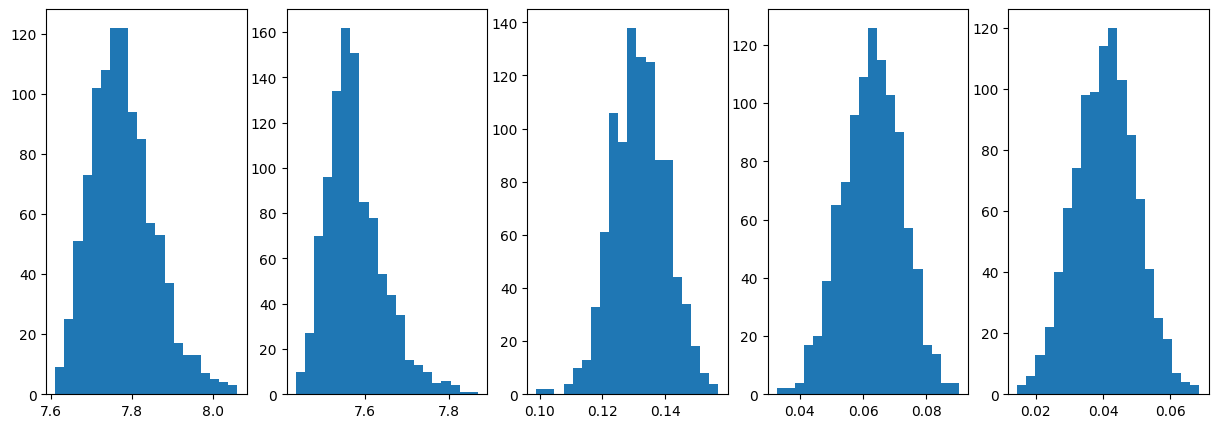

In [91]:
output_f = np.zeros((bs_std_meas_cap_f.bootstrap_distribution.shape[1], 5))

for i, xs in enumerate(bs_std_meas_cap_f.bootstrap_distribution.T):
    std_hc, pop_std, sig_v, pop_std_v, hba_mean = xs
    sig_tot = (pop_std**2 + std_hc**2)**0.5
    rho = pop_std**2/sig_tot**2
    mu_2, mu_3, p1, p2, p3 = calc_exp_values_2_3_MC(hba_mean, sig_tot, rho, 7.75)
    output_f[i] = mu_2, mu_3, p1, p2, p3
    
f, axs = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axs):
    ax.hist(output_f[:, i], bins=20);
output_f.mean(axis=0), np.quantile(output_f, 0.025, axis=0), np.quantile(output_f, 0.975, axis=0)

In [82]:
output_m = np.zeros((bs_std_meas_cap_m.bootstrap_distribution.shape[1], 5))
for i, xs in enumerate(bs_std_meas_cap_m.bootstrap_distribution.T):
    std_hc, pop_std, sig_v, pop_std_v, hba_mean = xs
    sig_tot = (pop_std**2 + std_hc**2)**0.5
    rho = pop_std**2/sig_tot**2
    mu_2, mu_3, p1, p2, p3 = calc_exp_values_2_3_MC(hba_mean, sig_tot, rho, 8.35)
    output_m[i] = mu_2, mu_3, p1, p2, p3
output_m.mean(axis=0), np.quantile(output_m, 0.025, axis=0), np.quantile(output_m, 0.975, axis=0)

(array([8.47222052, 8.23563252, 0.0629946 , 0.02570085, 0.01538016]),
 array([8.3427337 , 8.11872547, 0.05377318, 0.0175373 , 0.00863648]),
 array([8.6420949 , 8.38810489, 0.07272829, 0.03418962, 0.02292637]))

### Expectation values with CIs

In [92]:
ci_mean_m = scistats.bootstrap((df_m['Hb201a_'].values, ), statistic=np.mean)
ci_mean_f = scistats.bootstrap((df_f['Hb201a_'].values, ), statistic=np.mean)
print(ci_mean_m.confidence_interval)
print(ci_mean_f.confidence_interval)
df_m['Hb201a_'].mean(), df_f['Hb201a_'].mean()

ConfidenceInterval(low=np.float64(9.352452450487501), high=np.float64(9.425199709513436))
ConfidenceInterval(low=np.float64(8.430487804878048), high=np.float64(8.50227642276423))


(np.float64(9.388598402323893), np.float64(8.466097560975609))

In [93]:
ci_mean_m = scistats.bootstrap((df_m['Hb201b_'].values, ), statistic=np.nanmean)
ci_mean_f = scistats.bootstrap((df_f['Hb201b_'].values, ), statistic=np.nanmean)
print(ci_mean_m.confidence_interval)
print(ci_mean_f.confidence_interval)
df_m['Hb201b_'].mean(), df_f['Hb201b_'].mean()

ConfidenceInterval(low=np.float64(8.331818181818182), high=np.float64(8.59254331994552))
ConfidenceInterval(low=np.float64(7.602459016393443), high=np.float64(7.789565217391304))


(np.float64(8.4578125), np.float64(7.698437499999999))

In [ ]:
ci_mean_m = scistats.bootstrap((df_m['Hb201c_'].values, ), statistic=np.nanmean)
ci_mean_f = scistats.bootstrap((df_f['Hb201c_'].values, ), statistic=np.nanmean)
print(ci_mean_m.confidence_interval)
print(ci_mean_f.confidence_interval)
df_m['Hb201c_'].mean(), df_f['Hb201c_'].mean()

ConfidenceInterval(low=np.float64(8.015789473684212), high=np.float64(8.426550632046657))
ConfidenceInterval(low=np.float64(7.24593182859594), high=np.float64(7.512820512820513))


(np.float64(8.184999999999999), np.float64(7.3936170212765955))

In [111]:
scistats.bootstrap((df_m['Hb201b_'], ), statistic=lambda x: np.isfinite(x).sum())

BootstrapResult(confidence_interval=ConfidenceInterval(low=np.float64(50.0), high=np.float64(80.0)), bootstrap_distribution=array([64, 57, 57, ..., 55, 69, 67]), standard_error=np.float64(7.748761563686493))

In [81]:
(~df_f['Hb201a'].isna()).sum(), (~df_f['Hb201b'].isna()).sum(),(~df_f['Hb201c'].isna()).sum()

(np.int64(1230), np.int64(128), np.int64(47))

In [82]:
(~df_m['Hb201a'].isna()).sum(), (~df_m['Hb201b'].isna()).sum(),(~df_m['Hb201c'].isna()).sum(),

(np.int64(1377), np.int64(64), np.int64(20))

## Plot dist

In [83]:
sig_total_m = np.std(df_m["Hb201a_"])
sig_total_f = np.std(df_f["Hb201a_"])
print(sig_total_m, sig_total_f)
sig_meas_m = 0.38
sig_meas_f = 0.37
sig_pop_m = np.sqrt(sig_total_m**2 - sig_meas_m ** 2)
sig_pop_f = np.sqrt(sig_total_f**2 - sig_meas_f ** 2)
print(sig_pop_m, sig_pop_f)
rho_m = sig_pop_m**2 / sig_total_m**2
rho_f = sig_pop_f**2 / sig_total_f**2
print(rho_m, rho_f)
mu_pop_m = np.mean(df_m["Hb201a_"])
mu_pop_f = np.mean(df_f["Hb201a_"])
print(mu_pop_m, mu_pop_f)

0.6792018655976212 0.6421484950296528
0.562952195333928 0.5248377746207374
0.6869818985672421 0.6680042608223008
9.388598402323893 8.466097560975609


## Probability of meas below threshold

In [84]:
from scipy.integrate import quad

DR = 0.05  # adjust for rounding!


def calc_prob_below_1st(mu, sig, rho, cut):
    return scistats.norm.cdf(cut - DR, mu, sig)
    # return quad(scistats.norm.pdf, -np.inf, cut - DR, args=(mu, sig))[0]


def calc_prob_below_2nd(mu, sig, rho, cut):
    return scistats.multivariate_normal.cdf(
        [cut - DR, cut - DR], [mu, mu], [[sig**2, sig**2 * rho], [sig**2 * rho, sig**2]]
    )
    # return quad(pdf_cond_2nd_meas, -np.inf, cut - DR, args=(mu, sig, rho, cut - DR))[0]


def calc_prob_below_3rd(mu, sig, rho, cut):
    return scistats.multivariate_normal.cdf(
        [cut - DR, cut - DR, cut - DR],
        [mu, mu, mu],
        [
            [sig**2, sig**2 * rho, sig**2 * rho],
            [sig**2 * rho, sig**2, sig**2*rho],
            [sig**2 * rho, sig**2 * rho, sig**2],
        ],
    )
    # return quad(pdf_cond_3rd_meas, -np.inf, cut - DR, args=(mu, sig, rho, cut - DR))[0]


print(
    f"females 1st < cutoff = {calc_prob_below_1st(mu_pop_f, sig_total_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"females 2nd < cutoff = {calc_prob_below_2nd(mu_pop_f, sig_total_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"females 3rd < cutoff = {calc_prob_below_3rd(mu_pop_f, sig_total_f, rho_f, 7.75)*100:.1f}%"
)
print(
    f"males 1st < cutoff = {calc_prob_below_1st(mu_pop_m, sig_total_m, rho_m, 8.35)*100:.1f}%"
)
print(
    f"males 2nd < cutoff = {calc_prob_below_2nd(mu_pop_m, sig_total_m, rho_m, 8.35)*100:.1f}%"
)
print(
    f"males 3rd < cutoff = {calc_prob_below_3rd(mu_pop_m, sig_total_m, rho_m, 8.35)*100:.1f}%"
)

females 1st < cutoff = 11.6%
females 2nd < cutoff = 5.4%
females 3rd < cutoff = 3.4%
males 1st < cutoff = 5.4%
males 2nd < cutoff = 2.1%
males 3rd < cutoff = 1.2%


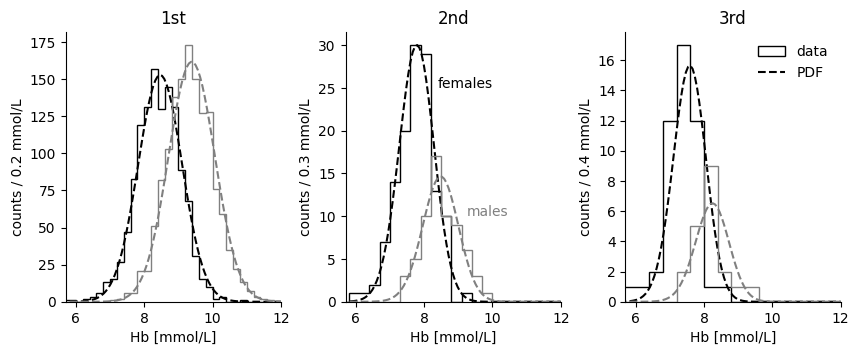

In [101]:
def plot_hist(x, ax, dbins, label=None, **kwargs):
    bins = np.arange(4.0, 14, dbins)
    h, b, pl = ax.hist(x, bins=bins, label=label, **kwargs)
    mb = (b[1:] + b[:-1]) / 2
    # TODO: correct uncertainties?
    mask = h > 0
    # ax.errorbar(mb[mask], h[mask], xerr=dbins/2, yerr=np.sqrt(h[mask]), ls='', color=kwargs['color'], label=label)
    # ax.bar(mb[mask], h[mask], width=dbins, edgecolor='none', fc=kwargs['color'], alpha=0.3)
    # ax.step(mb[mask], h[mask], where='mid', color=kwargs['color'])
    return mb, h


f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True)

female_color = "k"
female_kwargs = {"histtype": "step", "color": female_color}
plot_hist(df_f["Hb201a_"], ax1, dbins=0.2, **female_kwargs)
plot_hist(df_f["Hb201b_"], ax2, dbins=0.3, **female_kwargs)
plot_hist(df_f["Hb201c_"], ax3, dbins=0.4, label="data", **female_kwargs)
x = np.linspace(5.5, 12, 100)
ax1.plot(
    x,
    df_f["Hb201a_"].notna().sum() * 0.2 * scistats.norm.pdf(x, mu_pop_f, sig_total_f),
    color=female_color,
    ls="--",
)
ax2.plot(
    x,
    df_f["Hb201b_"].notna().sum()
    * 0.3
    * pdf_cond_2nd_meas(x, mu_pop_f, sig_total_f, rho_f, 7.75),
    color=female_color,
    ls="--",
)
ax3.plot(
    x,
    df_f["Hb201c_"].notna().sum()
    * 0.4
    * pdf_cond_3rd_meas(x, mu_pop_f, sig_total_f, rho_f, 7.75),
    color=female_color,
    label="PDF",
    ls="--",
)
male_color = "grey"
male_kwargs = {"histtype": "step", "color": male_color, "density": False, "ls": "-"}
plot_hist(df_m["Hb201a"], ax1, dbins=0.2, **male_kwargs)
plot_hist(df_m["Hb201b"], ax2, dbins=0.3, **male_kwargs)
plot_hist(df_m["Hb201c"], ax3, dbins=0.4, **male_kwargs)
ax1.plot(
    x,
    df_m["Hb201a_"].notna().sum() * 0.2 * scistats.norm.pdf(x, mu_pop_m, sig_total_m),
    color=male_color,
    ls="--",
)
ax2.plot(
    x,
    df_m["Hb201b_"].notna().sum()
    * 0.3
    * pdf_cond_2nd_meas(x, mu_pop_m, sig_total_m, rho_m, 8.35),
    color=male_color,
    ls="--",
)
ax3.plot(
    x,
    df_m["Hb201c_"].notna().sum()
    * 0.4
    * pdf_cond_3rd_meas(x, mu_pop_m, sig_total_m, rho_m, 8.35),
    color=male_color,
    ls="--",
)
ax2.annotate("males", xy=(9.25, 10), color=male_color)
ax2.annotate("females", xy=(8.4, 25), color=female_color)
ax3.legend(frameon=False)
ax1.set(ylabel="counts / 0.2 mmol/L", xlabel="Hb [mmol/L]", title="1st")
ax2.set(ylabel="counts / 0.3 mmol/L", xlabel="Hb [mmol/L]", title="2nd")
ax3.set(ylabel="counts / 0.4 mmol/L", xlabel="Hb [mmol/L]", title="3rd")
for ax in [ax1, ax2, ax3]:
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_xlim([5.7, 12])
    # ax.set_xlim([7.4, 8.])
    # ax.grid()
    
# columns = [('Males', 'observed'), ('Males', 'computed'), ('Females', 'observed'), ('Females', 'computed')]
# t1 = pd.DataFrame(np.zeros((2, 4)), columns=columns, index=['mean', 'count'])
# t1.columns = pd.MultiIndex.from_tuples(t1.columns)
# print(t1)
# t1_ = t1.T.reset_index().T.values[1:, :]
# ax1.table(, colnames=t1bbox=[0, -1, 1, 0.8])
f.subplots_adjust(wspace=0.3)
plt.savefig("Hb_dist_123_HAPPEN.pdf", bbox_inches="tight")  # , dpi=600)

In [87]:
df_don = pd.read_parquet('/mnt/c/Users/potha01m/data/processed_data/all_volbloed_since_2017.parquet',
                         columns=['KeyID', 'DonatieDateTime', 'Hb', 'Donatiesoortcode', 'Geslacht', 'Donatiecentrumcode'])
df_don["Hb"] = df_don["Hb"].mask((df_don["Hb"] < 2) | (df_don["Hb"] > 16))
df_don['ndons'] = df_don.groupby('KeyID').transform('size')
df_2024 = df_don.query('DonatieDateTime > 2024 & Donatiesoortcode == "V"')
print(len(df_2024), df_2024['KeyID'].nunique())
# df_don = df_don.query('DonatieDateTime > 2017 & DonatieDateTime < 2024 & ~Hb.isnull() & Donatiesoortcode == "N"')
# # df_don = df_don.query('Donatiecentrumcode not in ["AD250", "AD251"]')
# df_don = df_don.drop_duplicates('KeyID', keep='last')
# # df_don['Geslacht'] = df_don['Geslacht_x']

# len(df_don)

402616 221351


In [88]:
df_2024.loc[df_2024['Geslacht'] == "F", 'Hb_deferral'] = df_2024.loc[df_2024['Geslacht'] == "F", 'Hb'] < 7.8
df_2024.loc[df_2024['Geslacht'] == "M", 'Hb_deferral'] = df_2024.loc[df_2024['Geslacht'] == "M", 'Hb'] < 8.4

/tmp/ipykernel_3773/2720600603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024.loc[df_2024['Geslacht'] == "F", 'Hb_deferral'] = df_2024.loc[df_2024['Geslacht'] == "F", 'Hb'] < 7.8


In [89]:
df_2024.query('Donatiesoortcode == "V"')['Hb_deferral'].mean()

np.float64(0.03042601386929481)

In [90]:
df_2024.query('Donatiesoortcode == "V"').groupby('Geslacht')['Hb_deferral'].mean()

/tmp/ipykernel_3773/4143100582.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2024.query('Donatiesoortcode == "V"').groupby('Geslacht')['Hb_deferral'].mean()


Geslacht
          NaN
F    0.043721
M    0.016419
Name: Hb_deferral, dtype: object

In [91]:
def F3_max(x, mu, sig_tot, rho):
    # cdf of max of 3 correlated normals is same as cdf of triv norm
    var = sig_tot**2
    varrho = var * rho
    #slower
    # try:
    #     return np.array([nquad(trivariate_normal_cfunc_llc, [[-np.inf, x_], [-np.inf, x_], [-np.inf, x_]], args=(mu, sig, rho),
    #                         opts=dict(epsabs=1e-5, epsrel=1e-5))[0] for x_ in x])
    # except TypeError:
    #     return nquad(trivariate_normal_cfunc_llc, [[-np.inf, x], [-np.inf, x], [-np.inf, x]], args=(mu, sig, rho),
    #                                          opts=dict(epsabs=1e-5, epsrel=1e-5))[0]
    return scistats.multivariate_normal.cdf(
        np.dstack([x, x, x]),
        [mu, mu, mu],
        [[var, varrho, varrho], [varrho, var, varrho], [varrho, varrho, var]],
    )

def f3_max(x, mu, sig_tot, rho, dx=0.05):
    # take derivative (but poorly!) of cdf F3
    x_ = np.arange(x.min(), x.max(), dx)
    F3 = F3_max(x_, mu, sig_tot, rho)
    f3 = np.diff(F3, prepend=F3[0] / 2) / dx
    return np.interp(x, x_, f3)


def f2_max(x, mu, sig_tot, rho):
    x_ = (x - mu) / sig_tot
    return (
        2
        * scistats.norm.pdf(x_)
        * scistats.norm.cdf((1 - rho) / (1 - rho**2) ** 0.5 * x_)
    )


def pdf_comb(
    x, mu, sig, rho, cut, p_sjoemel=0.0, p_repeat_1=1, p_repeat_2=1, p_repeat_high=0
):
    dr = 0.05  # for rounding
    p1 = scistats.norm.cdf(cut - dr, mu, sig)  # prob of repeat once
    # p2 = quad(pdf_cond_2nd_meas, -np.inf, cut - dr, args=(mu, sig, rho, cut - dr))[
    #     0
    # ]  # prob of repeat twice
    var = sig**2
    varrho = var*rho
    p2 = scistats.multivariate_normal.cdf([cut-dr, cut-dr], [mu, mu], [[var, varrho], [varrho, var]])/p1
    # p3 = quad(pdf_cond_3rd_meas, -np.inf, cut - dr, args=(mu, sig, rho, cut - dr))[
    #     0
    # ]  # prob of taking max of 3
    p3 = scistats.multivariate_normal.cdf([cut-dr, cut-dr, cut-dr], [mu, mu, mu], [[var, varrho, varrho], [varrho, var, varrho], [varrho, varrho, var]])/(p1*p2)
    f1 = scistats.norm.pdf(x, mu, sig)
    f2 = pdf_cond_2nd_meas(x, mu, sig, rho, cut - dr)

    # no need to calculate below/above cut
    f3_copy = np.zeros_like(x)
    mask = x < cut - dr
    f3 = pdf_cond_3rd_meas(x[~mask], mu, sig, rho, cut - dr, norm=p2*p1)
    f3_copy[~mask] = f3
    f3 = f3_copy

    fmax_3_copy = np.zeros_like(x)
    fmax_3 = f3_max(x[mask], mu, sig, rho)
    norm_max_3 = F3_max(cut - dr, mu, sig, rho)
    fmax_3 /= norm_max_3
    fmax_3_copy[mask] = fmax_3
    fmax_3 = fmax_3_copy
    if p_repeat_high > 0:
        fmax_2 = f2_max(x, mu, sig, rho)  # normalize?
    else:
        fmax_2 = 0

    if isinstance(x, np.ndarray):
        f1[x < cut - dr] *= (1 - p_repeat_1) 
        f2[x < cut - dr] *= (1 - p_repeat_2) 
        if p_repeat_high > 0:
            fmax_2[x < cut - dr] *= (1 - p_repeat_1)
    else:
        raise NotImplementedError("use arrays")

    f_sjoemel = np.where(
        (x > cut - dr) & (x < cut + dr), 1 / (2 * dr), 0
    )  # sjoemel and round to cutoff
    fp1 = f1
    fp2 = (
        p1 * f2 * p_repeat_1 * (1 - p_repeat_high)
        + p1 * p_repeat_1 * fmax_2 * p_repeat_high
    )
    fp3 = p1 * p2 * f3 * p_repeat_1 * p_repeat_2
    fpmax = p1 * p2 * p3 * p_repeat_1 * p_repeat_2 * fmax_3
    return (fp1 + fp2 + fp3 + fpmax) * (1 - p_sjoemel) + p_sjoemel * f_sjoemel

0.9957547562306224
0.9995782213562834


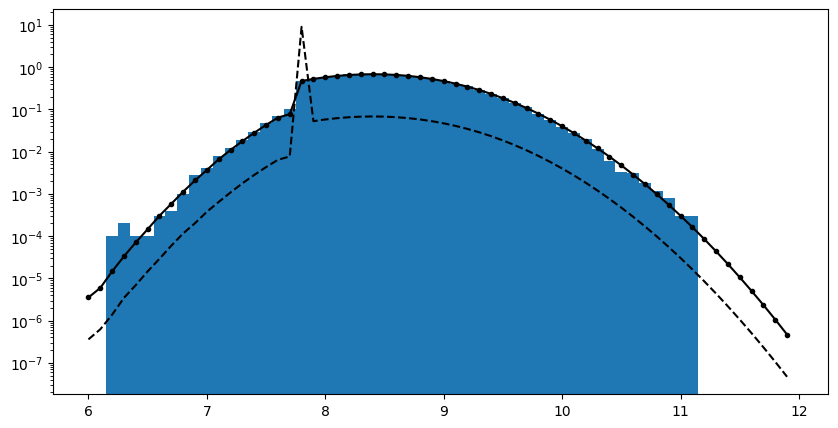

In [92]:
N = 100000
mu = 8.5
sig_pop = 0.5
sig_meas = 0.4
sig_tot = (0.5**2 + 0.4**2)**0.5
rho = 0.5**2/sig_tot**2
xtrue = np.random.normal(mu, sig_pop, N)
x1 = np.round(np.random.normal(xtrue, sig_meas), 1)
x2 = np.round(np.random.normal(xtrue, sig_meas), 1)
x3 = np.round(np.random.normal(xtrue, sig_meas), 1)
xmax = np.max([x1, x2, x3], axis=0)
cut = 7.8
xmeas = np.where(x1 < cut, np.where(x2 < cut, xmax, x2), x1)
plt.figure(figsize=(10, 5))
plt.hist(xmeas, bins=np.arange(6.05, 12, 0.1), density=True);
x = np.arange(6.0, 12, 0.1)
y = pdf_comb(x, mu, sig_tot, rho, cut, p_sjoemel=0.0)
print(y.sum()*0.1)
plt.plot(x, y, 'k.-')
y = pdf_comb(x, mu, sig_tot, rho, cut, p_sjoemel=0.9)
print(y.sum()*0.1)
plt.plot(x, y, 'k--')
# plt.xlim([7, 8.3])
plt.yscale('log')

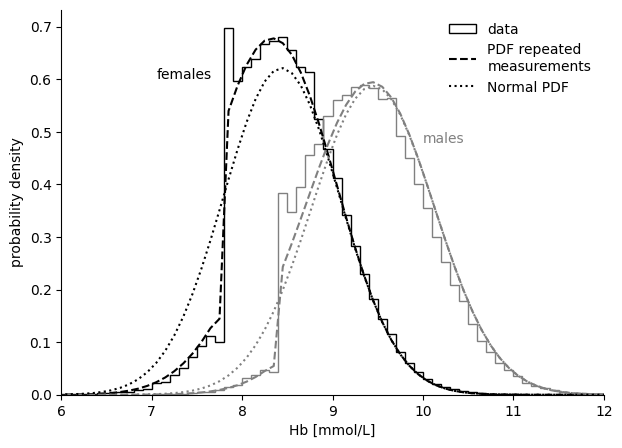

In [105]:

f, ax = plt.subplots(1, figsize=(7, 5))
Hb_f = df_don.query('Geslacht == "F"')['Hb'].values
Hb_m = df_don.query('Geslacht == "M"')['Hb'].values
x_f, h_f = plot_hist(Hb_f, ax=ax, dbins=0.1, color='k', density=True, histtype='step', label='data')
x_m, h_m = plot_hist(Hb_m, ax=ax, dbins=0.1, color='grey', density=True, histtype='step')


pdf_f = pdf_comb(x_f, mu_pop_f-0.03, sig_total_f, rho_f, 7.8, 0, 0.91, 0.67)
ax.plot(x_f, pdf_f, color='k', ls='--', label='PDF repeated\nmeasurements')
pdf_m = pdf_comb(x_m, mu_pop_m+0.06, sig_total_m, rho_m, 8.4, 0., 0.86, 0.7)
ax.plot(x_m, pdf_m, color='grey', ls='--')
ax.plot(x_m, scistats.norm.pdf(x_m, mu_pop_m+0.06, sig_total_m), ':', color='grey')
ax.plot(x_f, scistats.norm.pdf(x_f, mu_pop_f-0.03, sig_total_f), 'k:', label='Normal PDF')
ax.set(xlim=(6, 12), xlabel='Hb [mmol/L]', ylabel='probability density')
ax.legend(frameon=False)
ax.annotate('males', xy=(10.0, 0.48), color='grey')
ax.annotate('females', xy=(7.05, 0.6), color='k')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("Figure2.pdf", bbox_inches='tight', dpi=700)